# Data Analytics - Level 1, Task 2: Customer Segmentation Analysis
**OASIS Infobyte Internship**

**Objective:**
Perform customer segmentation using K-Means clustering on the Online Retail dataset. We will extract RFM (Recency, Frequency, Monetary) features, scale the data, determine the optimal number of clusters using the Elbow Method, and profile each customer segment to provide actionable marketing recommendations.

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set plot style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
import os
import zipfile

# Define the target Excel file name and the uploaded zip file path
excel_filename = 'Online Retail.xlsx'
zip_file_path = '/content/online+retail.zip'

# Check if the zip file exists and extract it
if os.path.exists(zip_file_path):
    print(f"Found '{zip_file_path}'. Unzipping it...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract all contents to the current directory
    print("Zip file unzipped successfully.")

    # Now, try to load the Excel file
    if os.path.exists(excel_filename):
        df = pd.read_excel(excel_filename)
        print("Dataset loaded successfully!")
    else:
        print(f"Error: '{excel_filename}' not found after unzipping '{zip_file_path}'.")
        print("Please check the exact name of the Excel file inside the zip archive.")
        print("Files in current directory after unzipping:", os.listdir('.'))
        raise FileNotFoundError(f"'{excel_filename}' not found after unzipping. Check file name inside zip.")
else:
    # If the zip file itself wasn't found, then the original error stands if the excel file isn't present
    print(f"Neither '{zip_file_path}' nor '{excel_filename}' found directly.")
    print("Please ensure 'Online Retail.xlsx' is uploaded, or if it's inside a zip, ensure the zip is uploaded.")
    raise FileNotFoundError(f"'{excel_filename}' not found. Please upload the file or the correct zip archive.")

Found '/content/online+retail.zip'. Unzipping it...
Zip file unzipped successfully.
Dataset loaded successfully!


In [18]:
# Display the first 5 rows
display(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
display(df.info())

# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None


Missing Values:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [19]:
# 1. Drop rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# 2. Remove cancelled orders and negative quantities/prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 3. Create a TotalAmount column for Monetary calculations
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Data cleaning complete.")
print(f"Remaining rows: {df_clean.shape[0]}")

Data cleaning complete.
Remaining rows: 397884


In [20]:
# Display descriptive statistics for Quantity, UnitPrice, and TotalAmount
print("Descriptive Statistics:")
display(df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].describe())

Descriptive Statistics:


,Quantity,UnitPrice,TotalAmount
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [21]:
import datetime as dt

# Set a reference date to 1 day after the last transaction in the dataset
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by CustomerID and calculate RFM metrics
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalAmount': 'sum'                                       # Monetary
}).reset_index()

# Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print("RFM Features Extracted:")
display(rfm.head())

RFM Features Extracted:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [22]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to the RFM columns
rfm_scaled_array = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Convert back to a DataFrame for easier plotting later
rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=['Recency', 'Frequency', 'Monetary'])

print("Data Standardization Complete:")
display(rfm_scaled.head())

Data Standardization Complete:


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


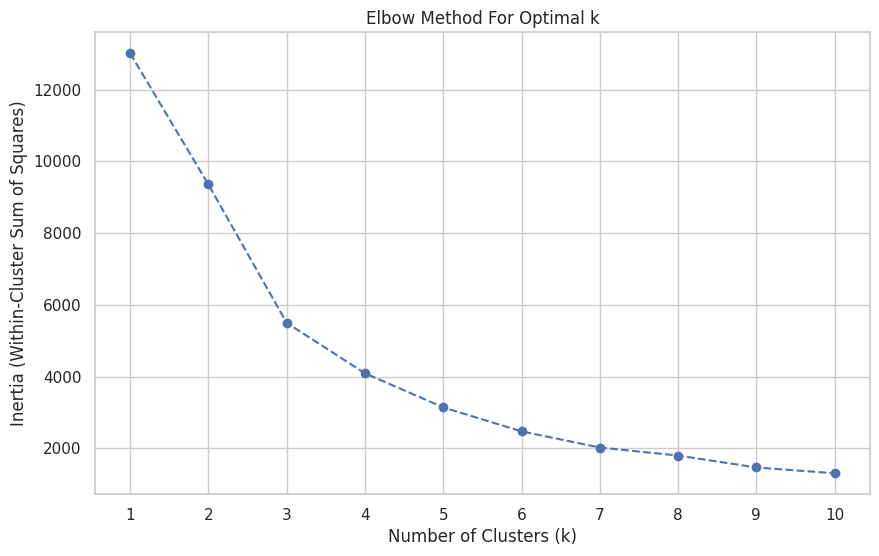

In [23]:
# Calculate inertia for different values of k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.show()

In [24]:
# Apply K-Means with k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

# Fit the model and assign clusters back to the original RFM dataframe
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"K-Means clustering applied with K={optimal_k}. First 5 rows:")
display(rfm.head())

K-Means clustering applied with K=4. First 5 rows:


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


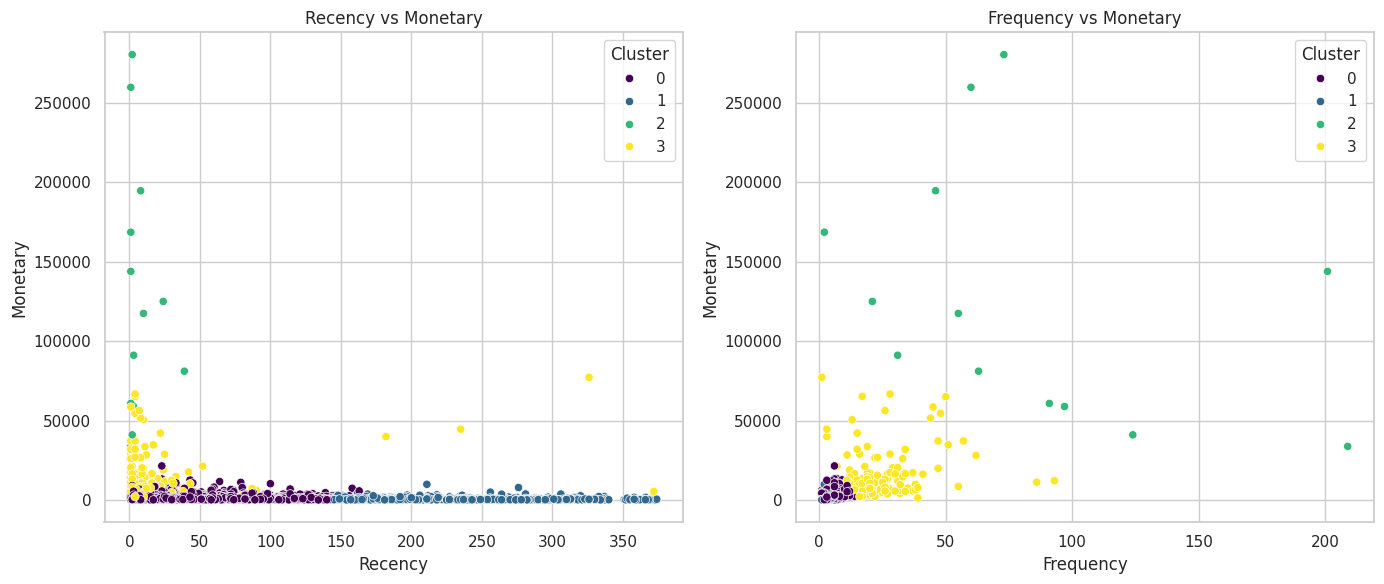

In [25]:
plt.figure(figsize=(14, 6))

# Scatter Plot 1: Recency vs Monetary
plt.subplot(1, 2, 1)
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Recency vs Monetary')

# Scatter Plot 2: Frequency vs Monetary
plt.subplot(1, 2, 2)
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Frequency vs Monetary')

plt.tight_layout()
plt.show()

Cluster Profiling (Mean Values):


,Cluster,Recency,Frequency,Monetary,Customer_Count
0,0,43.702685,3.682711,1359.049284,3054
1,1,248.075914,1.552015,480.617480,1067
2,2,7.384615,82.538462,127338.313846,13
3,3,15.500000,22.333333,12709.090490,204


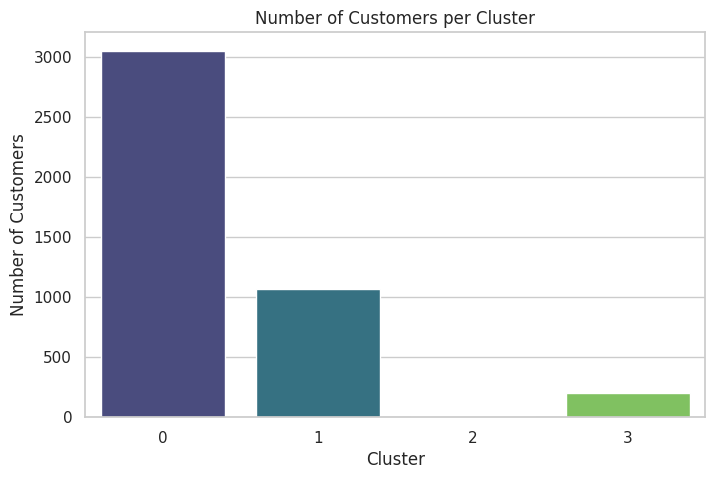

In [26]:
# Profile each cluster by calculating the mean of RFM features
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).reset_index()

cluster_profile.rename(columns={'CustomerID': 'Customer_Count'}, inplace=True)
print("Cluster Profiling (Mean Values):")
display(cluster_profile)

# Bar chart: Number of customers per cluster
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_profile, x='Cluster', y='Customer_Count', palette='viridis')
plt.title('Number of Customers per Cluster')
plt.ylabel('Number of Customers')
plt.show()

### 💡 Cluster Profiling & Marketing Recommendations

Based on our K-Means clustering, here is the business profile and recommended marketing action for each segment:

*   **The Champions (High Frequency, High Monetary, Low Recency):** These are your best customers.
    *   **Action:** Reward them. Offer loyalty programs, early access to new products, and personalized VIP experiences to maintain their brand advocacy.
*   **Recent & Promising (Low Recency, Low Frequency/Monetary):** Customers who recently made their first few purchases.
    *   **Action:** Build the relationship. Send welcome emails, onboarding guides, and small discounts on their next purchase to encourage repeat buying.
*   **At Risk (High Recency, Average Frequency/Monetary):** Customers who used to buy often but haven't visited in a while.
    *   **Action:** Send targeted win-back campaigns. Use personalized "We miss you" emails with time-limited discounts to incentivize a return visit.
*   **Lost / Hibernating (Very High Recency, Low Frequency/Monetary):** Customers who made a small purchase a long time ago and never returned.
    *   **Action:** Do not allocate heavy marketing budgets here. Keep them on standard promotional email lists, but focus primary acquisition and retention efforts on other segments.